In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set matplotlib & seaborn library settings : It keep our visualization simple,neat & clean
plt.style.use("default")
sns.set_context("notebook")              #It will tell seaborn to add text,lables and lines to our chart

# The Salary Dataset

## Questions

* What does the salary distribution looks like?
* Which job roles have the highest average salary?
* Which cities offer the highest average salary?
* Top 5 companies offering highest average salary.
* Top 5 companies with salaries reported more than 20 times?
* Is there any relationship between company rating and salary?
* Does employment rate affect salary?
* Which job roles are more common?
* How do salaries vary across locations?

In [76]:
#Load the dataset
df=pd.read_csv("Downloads/Salary_Dataset_DSL.csv")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


## Basic Data understanding

In [4]:
#To check number of rows and column in a dataset
df.shape

(22770, 8)

In [5]:
#To get info about dataset, like datatype,null values, column names
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [6]:
#To get statistic info of data
df.describe()

,Rating,Salary,Salaries Reported
count,22770.000000,2.277000e+04,22770.000000
mean,3.918213,6.953872e+05,1.855775
std,0.519675,8.843990e+05,6.823668
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [7]:
df.describe(include="all")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


## Data Cleaning

In [8]:
#Check missing values
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [9]:
#Replace the null value with a company name 
df['Company Name']=df['Company Name'].fillna('Unacademy')

In [10]:
#Now check that missing value is filled or not
df.isnull().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [11]:
#Remove duplicate rows
df=df.drop_duplicates()

#As we can see before checking duplicate rows and after checking we have same amount of rows and columns that mean we don't have any duplicate
df.shape

(22770, 8)

## Outlier detection and Removal

* Visualize Salary Outliers

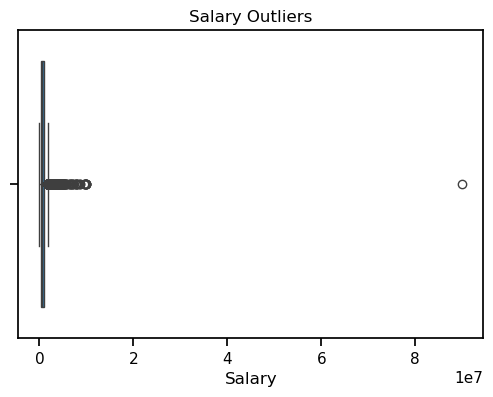

In [12]:
#Set a figure
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary Outliers")
plt.show()

In [13]:
#Remove outlier using Interquartile Range method (IQR method)
Q1=df['Salary'].quantile(0.25)
Q3=df['Salary'].quantile(0.75)

IQR=Q3-Q1

In [14]:
lower_l= Q1-1.5 * IQR
upper_l= Q3+1.5 * IQR

In [15]:
df=df[(df['Salary'] >=lower_l ) & (df['Salary']<=upper_l)]

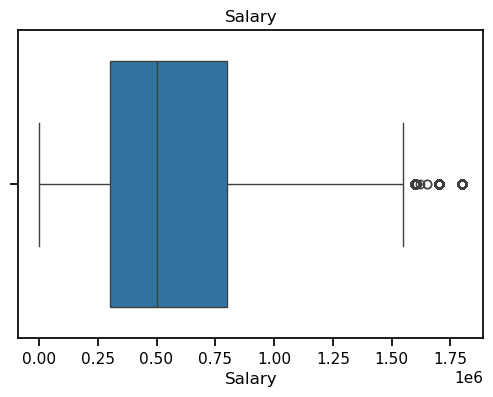

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Salary'])
plt.title("Salary")
plt.show()


## Univariate Aalysis

* Salary Distribution


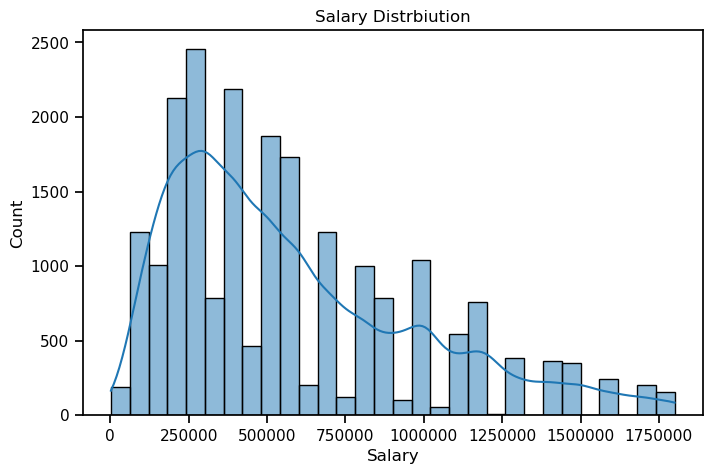

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], bins=30, kde=True)

#Change the exponential value into full value
plt.ticklabel_format(style='plain', axis='x')

plt.title('Salary Distrbiution')
plt.xlabel('Salary')
plt.show()

Most  of the salary range lies in lower to mid range (250000-750000). 

Means most of the people have lower or mid amount of salary and only a few of them have high salary

## Answer Business Questions

#### Q1: Which Job Roles have Highest Average Salary? 

In [18]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [19]:
#Check unqiue values in Job Roles

df['Job Roles'].nunique()

11

In [20]:
df['Job Roles'].unique()

array(['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java',
       'Mobile', 'SDE', 'Python', 'Web', 'Testing'], dtype=object)

In [21]:
#Check avg salary of each role
job_salary=df.groupby('Job Roles')['Salary'].mean().sort_values(ascending=False)
job_salary

Job Roles
Database    745670.833333
SDE         693104.775386
Mobile      648251.121076
IOS         617741.013470
Backend     574203.926740
Frontend    532927.754789
Android     501886.106443
Java        493755.957895
Testing     474144.130006
Python      460101.327641
Web         395296.404040
Name: Salary, dtype: float64

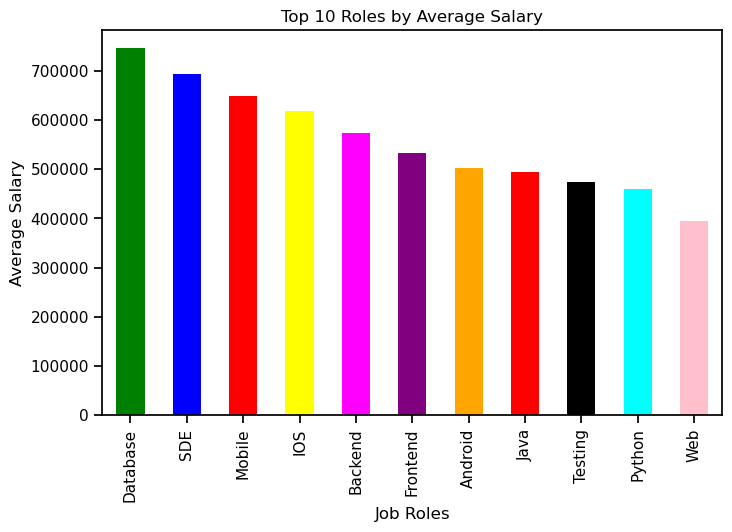

In [22]:
plt.figure(figsize=(8,5))
colors=['green','blue','red','yellow','magenta','purple','orange','red','black','cyan','pink']
job_salary.plot(kind='bar', color=colors)
plt.title("Top 10 Roles by Average Salary")
plt.ylabel('Average Salary')
plt.show()

As we can clearly see that Database Role have the highest salary while Web Job roles  has the lowest average salary

#### Q2:Which Cities Offer Highest Average Salary?

In [23]:
city_salary=df.groupby('Location')['Salary'].mean().sort_values(ascending=False)
city_salary

Location
Mumbai            752751.976155
Bangalore         606592.401189
Pune              594584.661125
Hyderabad         571350.134149
Kolkata           566359.281437
Jaipur            566153.846154
New Delhi         564724.843308
Chennai           523388.068763
Kerala            514965.735849
Madhya Pradesh    505600.644295
Name: Salary, dtype: float64

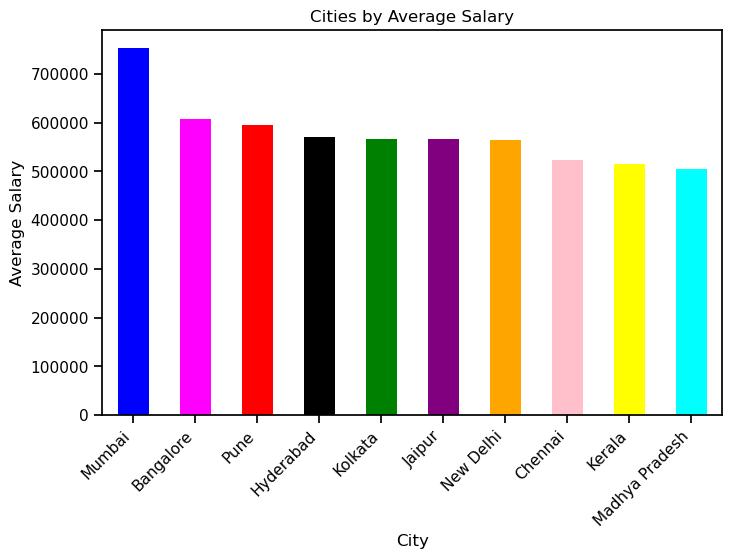

In [24]:
plt.figure(figsize=(8,5))
colors=['blue','magenta','red','black','green','purple','orange','pink','yellow','cyan','red']
city_salary.plot(kind='bar', color=colors)
plt.title("Cities by Average Salary")
plt.ylabel('Average Salary')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.show()

As we can see Mumbai has the highest Average Salary whereas Madhya Pradesh has the lowest.

#### Q3:Top 5 companies in Delhi with Rating 5 offering highest average salary.

In [25]:
delhi=df[(df['Location']=='New Delhi') & (df['Rating']==5)].sort_values(by='Salary',ascending=False)
delhi.head()


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
18393,5.0,Firevol,Software Development Engineer (SDE),1700000,1,New Delhi,Full Time,SDE
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS


In [26]:
list(delhi['Company Name'].head())

['Firevol',
 'Hapramp',
 'The Art of Mike Mignola',
 'Trillbit',
 'Silicon Valley Recycling']

C:\Users\Samman\AppData\Local\Temp\ipykernel_5876\1636670397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delhi['Company Name'].head(), y=delhi['Salary'].head(), palette='ocean')


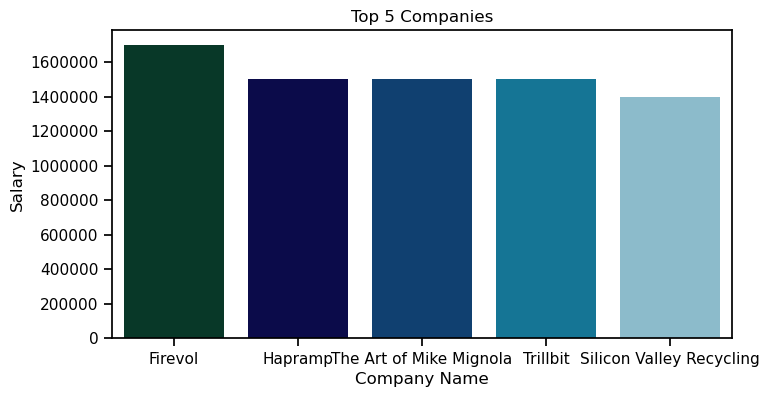

In [27]:
plt.figure(figsize=(8,4))
plt.ticklabel_format(style='plain', axis='y')
sns.barplot(x=delhi['Company Name'].head(), y=delhi['Salary'].head(), palette='ocean')
plt.title('Top 5 Companies')
plt.show()

#### Q4:Which Job Title has the highest number of Salary reported?

In [28]:
df['Job Title'].value_counts()

Job Title
Software Development Engineer          2225
Android Developer                      1998
Software Development Engineer (SDE)    1528
Front End Developer                    1384
Test Engineer                          1301
                                       ... 
Head of Mobile Development                1
Junior Front-End Web Developer            1
Mobile Tester                             1
Full Stack Mobile Developer               1
Associate Web Developer                   1
Name: count, Length: 1014, dtype: int64

In [29]:
df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending=False)

Job Title
Software Development Engineer                 2225
Android Developer                             1998
Software Development Engineer (SDE)           1528
Front End Developer                           1384
Test Engineer                                 1301
                                              ... 
IOS Lead                                         1
React Native and Python Developer - Intern       1
React Js Front End Developer                     1
React Front End Developer                        1
Xamarin Mobile Developer                         1
Name: Salaries Reported, Length: 1014, dtype: int64

Software Development Enginner, Android Developer and Front End Developer have the highest number of Salary Reported.

#### Q5:Which 5 companies provide the highest average salary when atleast 20 employees have reported their salaries

In [30]:
filter_df=df[df['Salaries Reported'] >=20]

In [31]:
filter_df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [32]:
#Calculate average salary of filtered data
top5=filter_df.groupby('Company Name')['Salary'].mean().sort_values(ascending=False).head()
top5

Company Name
Expedia Group        1350000.0
Cisco Systems        1250000.0
Amadeus              1200000.0
Nokia                1200000.0
Dell Technologies    1000000.0
Name: Salary, dtype: float64

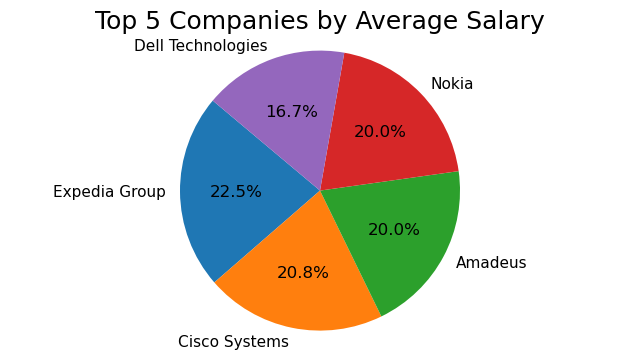

In [33]:
#Make a piechart of it
import matplotlib.pyplot as plt

# Data
labels = top5.index
value = top5.values

# Plot
plt.figure(figsize=(8, 4))
plt.pie(
    value,
    labels=labels,
    autopct='%1.1f%%',   # shows percentage
    startangle=140
)

plt.title('Top 5 Companies by Average Salary',fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()

#### Q6:Check and show relationship between Ratings & Salaries.

In [34]:
#To check coorelation between numeric columns
df['Rating'].corr(df['Salary'])

np.float64(0.028435446014226984)

As we can clearly see that Company Salary and Rating doesn't have a strong relationshiop between them.

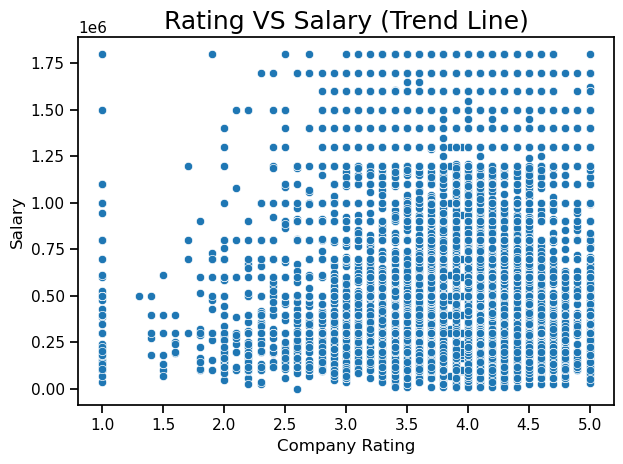

In [35]:
sns.scatterplot(x='Rating', y='Salary', data=df)
plt.title('Rating VS Salary (Trend Line)', fontsize=18)
plt.xlabel('Company Rating')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

#### Q7:Does Employment status affect Salary?

In [36]:
df['Employment Status'].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [37]:
df['Employment Status'].value_counts()

Employment Status
Full Time     18966
Intern         2092
Contractor      523
Trainee          33
Name: count, dtype: int64

In [38]:
emp_data=df.groupby('Employment Status')['Salary'].mean()
emp_data

Employment Status
Contractor    523849.697897
Full Time     613544.648740
Intern        340258.837476
Trainee       324303.030303
Name: Salary, dtype: float64

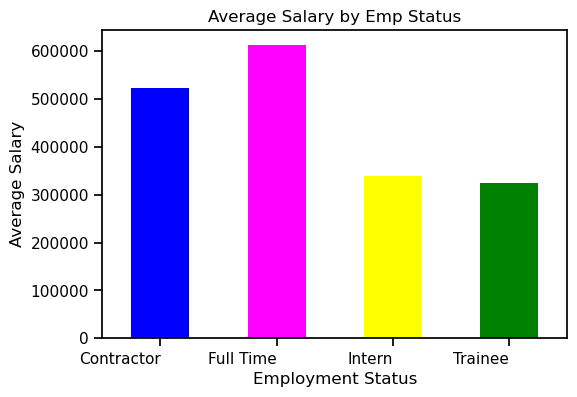

In [39]:
plt.figure(figsize=(6,4))
colors=['blue','magenta','yellow','green']
emp_data.plot(kind='bar', color=colors)
plt.title("Average Salary by Emp Status")
plt.ylabel('Average Salary')
plt.xlabel('Employment Status')
plt.xticks(rotation=0, ha='right')
plt.show()

As we can clearly see that Full time Employees has the highest avg Salary while Trainnes has the lowest.

#### Q8:Which Job Roles are most common

In [40]:
df['Job Roles'].value_counts()

Job Roles
SDE         7573
Android     2856
Frontend    2088
Java        1805
Testing     1723
IOS         1559
Backend     1092
Web          990
Python       937
Database     768
Mobile       223
Name: count, dtype: int64

In [43]:
top_role=df['Job Roles'].value_counts().head(8)
top_role

Job Roles
SDE         7573
Android     2856
Frontend    2088
Java        1805
Testing     1723
IOS         1559
Backend     1092
Web          990
Name: count, dtype: int64

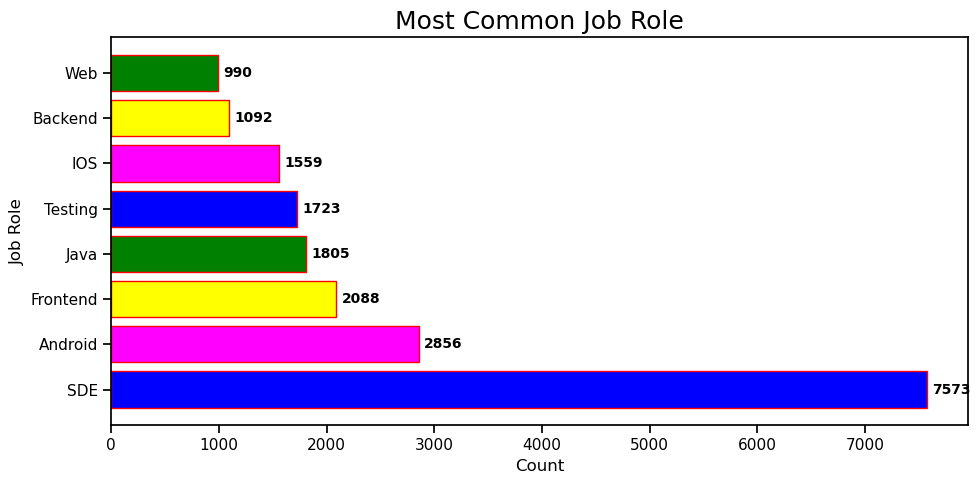

In [57]:
plt.figure(figsize=(10,5))

#use gradient color
color=sns.color_palette("hsv", len(top_role))

#Horizontal barchat
plt.barh(top_role.index, top_role.values, color=colors, edgecolor='red')

#Add lables on bar
for i,v in enumerate(top_role.values):
    plt.text(v+50, i, str(v), va='center', fontsize=10, fontweight='bold')


# Labels and title
plt.ylabel('Job Role')
plt.xlabel('Count')
plt.title('Most Common Job Role', fontsize=18)

plt.tight_layout()
plt.show()

As we can see SDE, Andriod and Frontend are the most common Job Roles.

#### Q9:How does average salary change as company rating increases?

In [61]:
rating_salary=df.groupby('Rating')['Salary'].mean().reset_index()
rating_salary.head()


,Rating,Salary
0,1.0,421510.400000
1,1.3,500000.000000
2,1.4,331200.000000
3,1.5,241000.000000
4,1.6,262285.714286


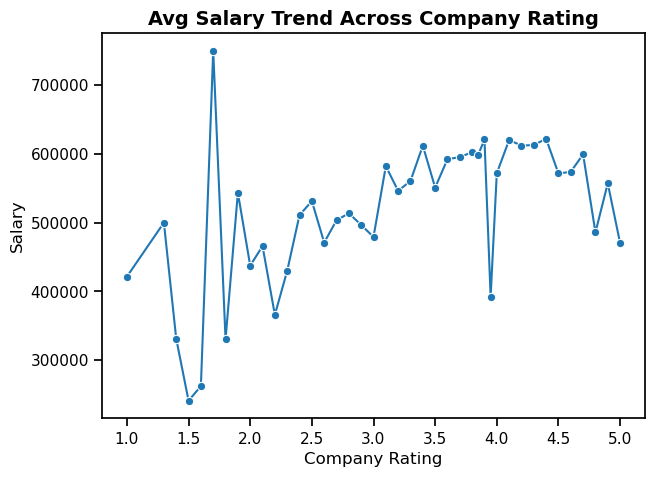

In [65]:
#Make a line chart of it
plt.figure(figsize=(7,5))

sns.lineplot(x='Rating', y='Salary', data=rating_salary, marker='o')
plt.title("Avg Salary Trend Across Company Rating", fontsize=14, fontweight='bold')
plt.xlabel("Company Rating")
plt.show()

As we can see most of the Salary is between Rating 3.0 to 4.5 .

## Mini Dashboard

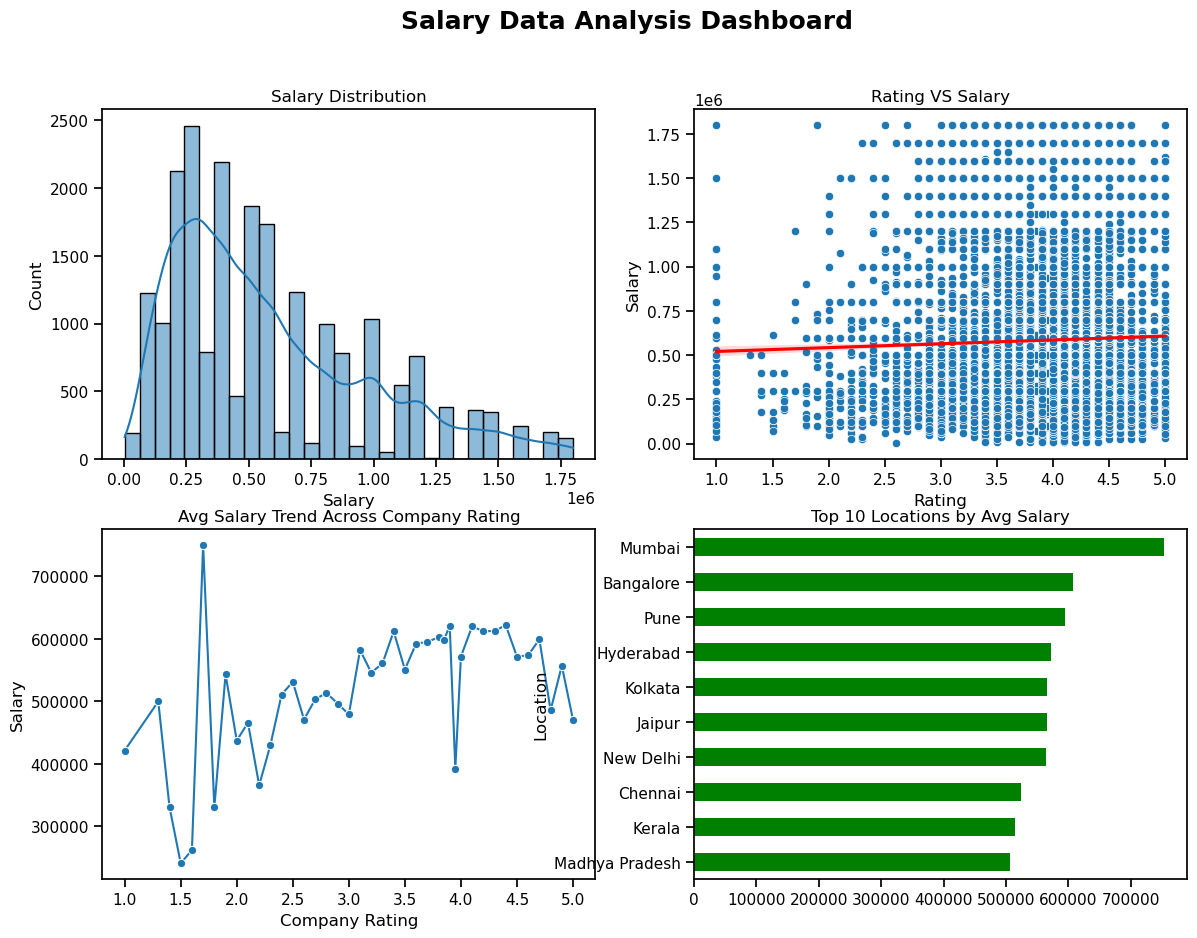

In [74]:
#Prepare Data
rating_salary=df.groupby('Rating')['Salary'].mean().reset_index()
top_locations=df.groupby('Location')['Salary'].mean().sort_values(ascending=False)

#Create Dashboard
plt.figure(figsize=(14,10))

#1:Salary Distribution
plt.subplot(2,2,1)
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title('Salary Distribution')

#2:Rating VS Salary
plt.subplot(2,2,2)
sns.scatterplot(x='Rating', y='Salary', data=df)
sns.regplot(x='Rating', y='Salary', data=df , scatter=False , color='red')
plt.title('Rating VS Salary')

#3:Avg Salary by Rating
plt.subplot(2,2,3)
sns.lineplot(x='Rating', y='Salary', data=rating_salary, marker='o')
plt.title("Avg Salary Trend Across Company Rating")
plt.xlabel("Company Rating")

#4:Top LOcation
plt.subplot(2,2,4)
top_locations.sort_values().plot(kind='barh' , color='green')
plt.title('Top 10 Locations by Avg Salary')

plt.suptitle("Salary Data Analysis Dashboard", fontsize=18 , fontweight='bold')
plt.show()